  Device  : cuda
  Classes : ['2', '4', '5', '6', '7']
  Emotions: {'2': 'Fear', '4': 'Happiness', '5': 'Sadness', '6': 'Anger', '7': 'Neutral'}

📁  Loading data …

📊 TRAIN SET — VALUE COUNTS
----------------------------------------
Happiness    4772
Neutral      2524
Sadness      1982
Anger         705
Fear          281
   Total : 10264

📊 TEST  SET — VALUE COUNTS
----------------------------------------
Happiness    1185
Neutral       680
Sadness       478
Anger         162
Fear           74
   Total : 2579


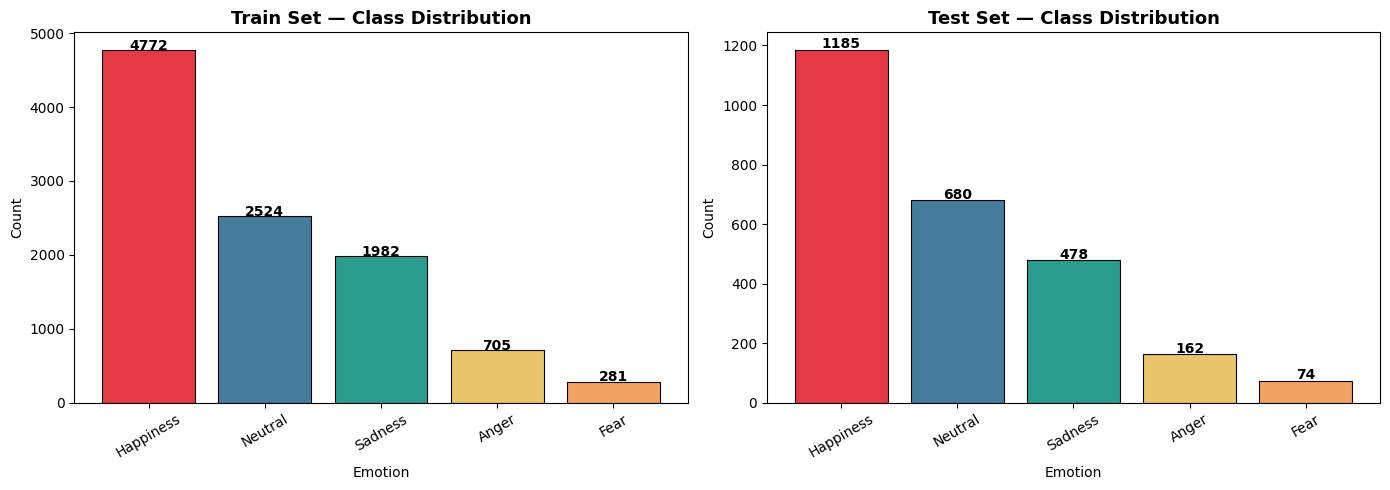


✅  Saved: /kaggle/working/emotion_model/class_distribution.png

⚖️   Class Weights (Cost-Sensitive / Balanced):
   idx 0  Fear         → 7.3053
   idx 1  Happiness    → 0.4302
   idx 2  Sadness      → 1.0357
   idx 3  Anger        → 2.9118
   idx 4  Neutral      → 0.8133

📂  Train batches: 320  |  Test batches: 81
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 151MB/s]



🧠  DenseNet-121  |  total=7,484,293  trainable=7,484,293

  🏋️   TRAINING
  Ep   1/60 | tr_loss 1.7431  tr_acc 0.4332 | val_loss 1.8635  val_acc 0.5425 | lr 3.00e-04  ES 0/12 ✅
  Ep   2/60 | tr_loss 1.4221  tr_acc 0.6390 | val_loss 1.7130  val_acc 0.6522 | lr 2.99e-04  ES 0/12 ✅
  Ep   3/60 | tr_loss 1.2995  tr_acc 0.7142 | val_loss 1.8339  val_acc 0.5762 | lr 2.98e-04  ES 1/12   
  Ep   4/60 | tr_loss 1.2205  tr_acc 0.7666 | val_loss 1.5354  val_acc 0.7677 | lr 2.97e-04  ES 0/12 ✅
  Ep   5/60 | tr_loss 1.1882  tr_acc 0.7802 | val_loss 1.4848  val_acc 0.7929 | lr 2.95e-04  ES 0/12 ✅
  Ep   6/60 | tr_loss 1.1604  tr_acc 0.7999 | val_loss 1.4478  val_acc 0.8096 | lr 2.93e-04  ES 0/12 ✅
  Ep   7/60 | tr_loss 1.1196  tr_acc 0.8176 | val_loss 1.4754  val_acc 0.7972 | lr 2.90e-04  ES 1/12   
  Ep   8/60 | tr_loss 1.1130  tr_acc 0.8230 | val_loss 1.4809  val_acc 0.7716 | lr 2.87e-04  ES 2/12   
  Ep   9/60 | tr_loss 1.0833  tr_acc 0.8463 | val_loss 1.4765  val_acc 0.7922 | lr 2.84e-04  ES 3/

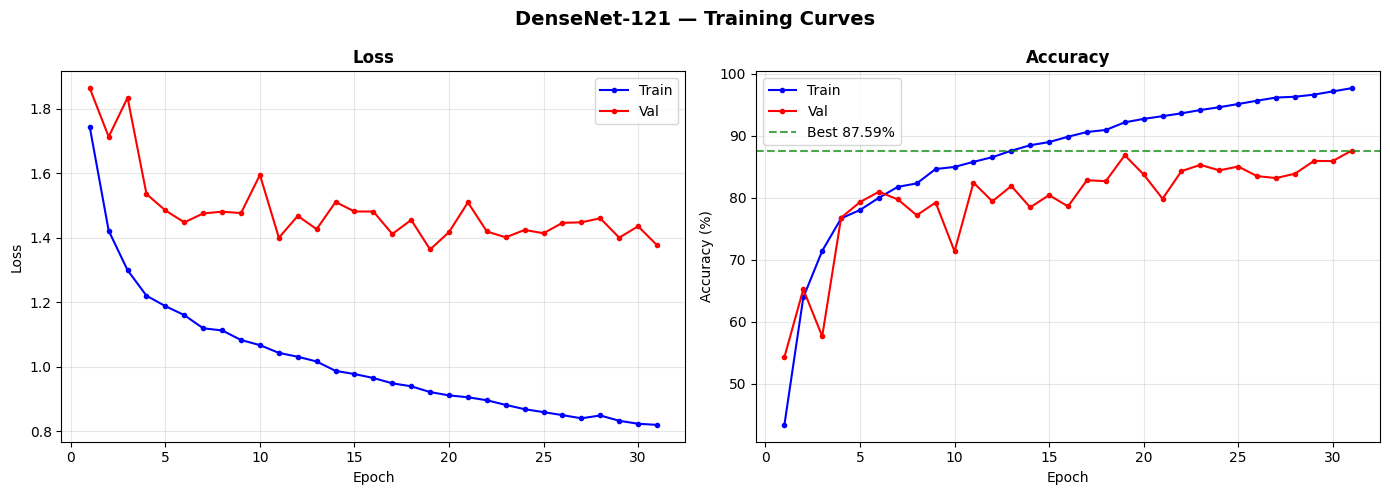

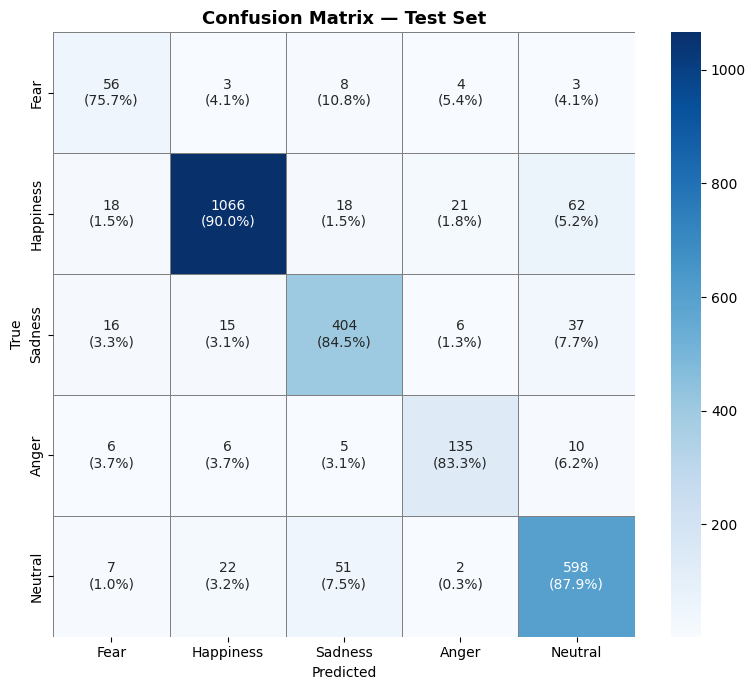

✅  Plots saved.


In [1]:
#!/usr/bin/env python3
"""
╔══════════════════════════════════════════════════════════════╗
║   RAF-DB Face Emotion Recognition — Complete Training Script ║
║   Model     : DenseNet121 (Pretrained + Cost-Sensitive)      ║
║   Optimizer : AdamW                                          ║
║   Scheduler : Cosine Annealing LR                            ║
║   Stopping  : Early Stopping                                 ║
║   Classes   : Fear·Happiness·Sadness·Anger·Neutral           ║
╚══════════════════════════════════════════════════════════════╝

Run on Kaggle with GPU.  Everything you need is zipped and
saved to /kaggle/working/emotion_model_complete.zip

OUTPUTS
  best_model.pth              ← PyTorch weights (best val acc)
  final_model.pth             ← PyTorch weights (last epoch)
  emotion_model.onnx          ← ONNX export  (Jetson Nano / TRT)
  model_config.json           ← class maps + normalisation stats
  label_encoder.json          ← index ↔ emotion label
  class_distribution.png
  training_curves.png
  confusion_matrix.png
  classification_report.txt
  live_camera_inference.py    ← VSCode live-cam script
  video_inference.py          ← VSCode video-file script
  jetson_nano_inference.py    ← Jetson Nano (GStreamer / USB cam)
  requirements.txt
  README.md
  emotion_model_complete.zip  ← DOWNLOAD THIS
"""

# ═══════════════════════════════════════════════════════════════
# 0.  INSTALL EXTRAS (run once on Kaggle)
# ═══════════════════════════════════════════════════════════════
import subprocess, sys
for pkg in ["onnx", "onnxruntime", "onnxscript"]:   
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                   capture_output=True)

# ═══════════════════════════════════════════════════════════════
# 1.  IMPORTS
# ═══════════════════════════════════════════════════════════════
import os, json, time, random, warnings, zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
# 2.  CONFIG
# ═══════════════════════════════════════════════════════════════
CONFIG = {
    # ── paths ──────────────────────────────────────────────────
    "train_path": "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train",
    "test_path" : "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    "output_dir": "/kaggle/working/emotion_model",

    # ── classes (SKIP 1=Surprise, 3=Disgust) ───────────────────
    "selected_classes": ["2", "4", "5", "6", "7"],
    "emotion_map": {
        "2": "Fear",
        "4": "Happiness",
        "5": "Sadness",
        "6": "Anger",
        "7": "Neutral",
    },

    # ── training ───────────────────────────────────────────────
    "image_size"   : 224,
    "batch_size"   : 32,
    "num_epochs"   : 60,
    "lr"           : 3e-4,
    "weight_decay" : 1e-4,
    "patience"     : 12,       # early-stopping patience
    "num_workers"  : 4,
    "seed"         : 42,

    # ── scheduler ──────────────────────────────────────────────
    "T_max"        : 60,
    "eta_min"      : 1e-6,

    # ── model ──────────────────────────────────────────────────
    "num_classes"  : 5,
    "dropout"      : 0.50,

    # ── normalisation (ImageNet) ────────────────────────────────
    "mean" : [0.485, 0.456, 0.406],
    "std"  : [0.229, 0.224, 0.225],
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# label → index  (sorted order): '2'→0, '4'→1, '5'→2, '6'→3, '7'→4
LABEL_ENC     = {c: i for i, c in enumerate(sorted(CONFIG["selected_classes"]))}
IDX_TO_EMOTION = {i: CONFIG["emotion_map"][c] for c, i in LABEL_ENC.items()}
IDX_TO_CLASS  = {i: c for c, i in LABEL_ENC.items()}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

# ═══════════════════════════════════════════════════════════════
# 3.  REPRODUCIBILITY
# ═══════════════════════════════════════════════════════════════
def set_seed(s: int) -> None:
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CONFIG["seed"])

print("=" * 60)
print(f"  Device  : {DEVICE}")
print(f"  Classes : {CONFIG['selected_classes']}")
print(f"  Emotions: {CONFIG['emotion_map']}")
print("=" * 60)

# ═══════════════════════════════════════════════════════════════
# 4.  DATA LOADING & VALUE COUNTS
# ═══════════════════════════════════════════════════════════════
def load_paths(base: str, classes: list[str]):
    paths, labels, counts = [], [], {}
    for cls in sorted(classes):
        folder = os.path.join(base, cls)
        if not os.path.isdir(folder):
            print(f"  ⚠  Folder not found: {folder}")
            continue
        imgs = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        counts[cls] = len(imgs)
        paths.extend(imgs)
        labels.extend([cls] * len(imgs))
    return paths, labels, counts


print("\n📁  Loading data …")
tr_paths, tr_labels, tr_counts = load_paths(CONFIG["train_path"], CONFIG["selected_classes"])
te_paths, te_labels, te_counts = load_paths(CONFIG["test_path"],  CONFIG["selected_classes"])

# ── Value Counts ────────────────────────────────────────────────
def print_vc(labels, tag):
    vc = pd.Series([CONFIG["emotion_map"][l] for l in labels]).value_counts()
    print(f"\n📊 {tag} — VALUE COUNTS")
    print("-" * 40)
    print(vc.to_string())
    print(f"   Total : {len(labels)}")
    return vc

tr_vc = print_vc(tr_labels, "TRAIN SET")
te_vc = print_vc(te_labels,  "TEST  SET")

# ── Class-distribution bar charts ───────────────────────────────
PALETTE = ["#E63946","#457B9D","#2A9D8F","#E9C46A","#F4A261"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vc, title in zip(axes, [tr_vc, te_vc], ["Train", "Test"]):
    bars = ax.bar(vc.index, vc.values, color=PALETTE, edgecolor="black", linewidth=0.8)
    ax.set_title(f"{title} Set — Class Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Emotion");  ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
dist_png = os.path.join(CONFIG["output_dir"], "class_distribution.png")
plt.savefig(dist_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅  Saved: {dist_png}")

# ═══════════════════════════════════════════════════════════════
# 5.  COST-SENSITIVE CLASS WEIGHTS
# ═══════════════════════════════════════════════════════════════
int_labels = np.array([LABEL_ENC[l] for l in tr_labels])
cw = compute_class_weight("balanced", classes=np.arange(CONFIG["num_classes"]), y=int_labels)
CLASS_WEIGHTS = torch.FloatTensor(cw).to(DEVICE)

print("\n⚖️   Class Weights (Cost-Sensitive / Balanced):")
for i, (w, em) in enumerate(zip(cw, [IDX_TO_EMOTION[i] for i in range(CONFIG["num_classes"])])):
    print(f"   idx {i}  {em:<12} → {w:.4f}")

# ═══════════════════════════════════════════════════════════════
# 6.  DATASET & TRANSFORMS
# ═══════════════════════════════════════════════════════════════
def get_transforms(phase: str):
    if phase == "train":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            transforms.RandomGrayscale(p=0.08),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ToTensor(),
            transforms.Normalize(CONFIG["mean"], CONFIG["std"]),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(CONFIG["mean"], CONFIG["std"]),
    ])


class EmotionDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = [LABEL_ENC[l] for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


tr_ds = EmotionDataset(tr_paths, tr_labels, get_transforms("train"))
te_ds = EmotionDataset(te_paths, te_labels, get_transforms("val"))

tr_dl = DataLoader(tr_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                   num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
te_dl = DataLoader(te_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                   num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"\n📂  Train batches: {len(tr_dl)}  |  Test batches: {len(te_dl)}")

# ═══════════════════════════════════════════════════════════════
# 7.  MODEL — DenseNet121 with custom head
# ═══════════════════════════════════════════════════════════════
class EmotionDenseNet(nn.Module):
    """
    DenseNet-121 backbone with a two-layer classification head.
    The original single-linear classifier is replaced by:
        BN → Dropout → FC(1024→512) → ReLU → BN → Dropout → FC(512→num_cls)
    """
    def __init__(self, num_classes: int = 5, dropout: float = 0.5):
        super().__init__()
        backbone              = models.densenet121(weights="IMAGENET1K_V1")
        in_feat               = backbone.classifier.in_features   # 1024
        backbone.classifier   = nn.Sequential(
            nn.BatchNorm1d(in_feat),
            nn.Dropout(dropout),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout * 0.6),
            nn.Linear(512, num_classes),
        )
        self.net = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = EmotionDenseNet(CONFIG["num_classes"], CONFIG["dropout"]).to(DEVICE)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🧠  DenseNet-121  |  total={n_total:,}  trainable={n_trainable:,}")

# ═══════════════════════════════════════════════════════════════
# 8.  LOSS, OPTIMISER, SCHEDULER
# ═══════════════════════════════════════════════════════════════
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.1)
optimizer  = optim.AdamW(model.parameters(),
                         lr=CONFIG["lr"],
                         weight_decay=CONFIG["weight_decay"])
scheduler  = CosineAnnealingLR(optimizer,
                                T_max=CONFIG["T_max"],
                                eta_min=CONFIG["eta_min"])

# ═══════════════════════════════════════════════════════════════
# 9.  EARLY STOPPING
# ═══════════════════════════════════════════════════════════════
class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best       = float("inf")
        self.stop       = False

    def __call__(self, val_loss: float) -> bool:
        """Returns True if improved."""
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False


# ═══════════════════════════════════════════════════════════════
# 10.  TRAIN / EVAL HELPERS
# ═══════════════════════════════════════════════════════════════
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, targets in loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, targets)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(1)
            correct    += preds.eq(targets).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_targets


# ═══════════════════════════════════════════════════════════════
# 11.  TRAINING LOOP
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  🏋️   TRAINING")
print("=" * 60)

hist = {"tr_loss":[], "tr_acc":[], "val_loss":[], "val_acc":[]}
es            = EarlyStopping(patience=CONFIG["patience"])
best_val_acc  = 0.0
best_epoch    = 0
t0            = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    tr_loss, tr_acc, _, _          = run_epoch(model, tr_dl, criterion, optimizer)
    val_loss, val_acc, vp, vt      = run_epoch(model, te_dl, criterion)
    scheduler.step()

    hist["tr_loss"].append(tr_loss)
    hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(val_loss)
    hist["val_acc"].append(val_acc)

    improved = es(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        torch.save({
            "epoch"            : epoch,
            "model_state_dict" : model.state_dict(),
            "optimizer_state"  : optimizer.state_dict(),
            "val_acc"          : val_acc,
            "val_loss"         : val_loss,
            "config"           : CONFIG,
            "label_enc"        : LABEL_ENC,
            "idx_to_emotion"   : IDX_TO_EMOTION,
        }, os.path.join(CONFIG["output_dir"], "best_model.pth"))

    cur_lr = scheduler.get_last_lr()[0]
    flag   = "✅" if improved else "  "
    print(
        f"  Ep {epoch:3d}/{CONFIG['num_epochs']} "
        f"| tr_loss {tr_loss:.4f}  tr_acc {tr_acc:.4f} "
        f"| val_loss {val_loss:.4f}  val_acc {val_acc:.4f} "
        f"| lr {cur_lr:.2e}  ES {es.counter}/{CONFIG['patience']} {flag}"
    )

    if es.stop:
        print(f"\n  ⛔  Early stopping @ epoch {epoch}")
        break

train_min = (time.time() - t0) / 60
print(f"\n  ✅  Done in {train_min:.1f} min  |  best val_acc={best_val_acc:.4f} @ epoch {best_epoch}")

# Save final weights
torch.save({
    "epoch"            : epoch,
    "model_state_dict" : model.state_dict(),
    "config"           : CONFIG,
    "label_enc"        : LABEL_ENC,
    "idx_to_emotion"   : IDX_TO_EMOTION,
}, os.path.join(CONFIG["output_dir"], "final_model.pth"))

# ═══════════════════════════════════════════════════════════════
# 12.  EVALUATION ON TEST SET (best model)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  📊  TEST EVALUATION  (best checkpoint)")
print("=" * 60)

ckpt = torch.load(os.path.join(CONFIG["output_dir"], "best_model.pth"), map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

_, test_acc, test_preds, test_targets = run_epoch(model, te_dl, criterion)
EM_NAMES = [IDX_TO_EMOTION[i] for i in range(CONFIG["num_classes"])]

print(f"\n  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro F1      : {f1_score(test_targets, test_preds, average='macro'):.4f}")
print(f"\n  Classification Report:")
rpt = classification_report(test_targets, test_preds, target_names=EM_NAMES, digits=4)
print(rpt)

with open(os.path.join(CONFIG["output_dir"], "classification_report.txt"), "w") as f:
    f.write(f"Test Accuracy : {test_acc:.4f}\n\n{rpt}")

# ═══════════════════════════════════════════════════════════════
# 13.  PLOTS
# ═══════════════════════════════════════════════════════════════
eps = range(1, len(hist["tr_loss"]) + 1)

# ── Training curves ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(eps, hist["tr_loss"],  "b-o", ms=3, label="Train")
ax1.plot(eps, hist["val_loss"], "r-o", ms=3, label="Val")
ax1.set_title("Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eps, [a*100 for a in hist["tr_acc"]],  "b-o", ms=3, label="Train")
ax2.plot(eps, [a*100 for a in hist["val_acc"]],  "r-o", ms=3, label="Val")
ax2.axhline(best_val_acc*100, ls="--", c="green", alpha=0.7,
            label=f"Best {best_val_acc*100:.2f}%")
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("DenseNet-121 — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "training_curves.png"), dpi=150)
plt.show()

# ── Confusion matrix ────────────────────────────────────────────
cm = confusion_matrix(test_targets, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8, 7))
annot = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(r, q)]
                   for r, q in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt="s", cmap="Blues",
            xticklabels=EM_NAMES, yticklabels=EM_NAMES,
            linewidths=0.5, linecolor="gray")
plt.title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.ylabel("True");  plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "confusion_matrix.png"), dpi=150)
plt.show()
print("✅  Plots saved.")


In [2]:
!pip install -qq onnxscript


In [3]:

# ═══════════════════════════════════════════════════════════════
# 14.  ONNX EXPORT  (Jetson Nano / TensorRT)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  📦  ONNX EXPORT")
print("=" * 60)

model.eval()
dummy   = torch.randn(1, 3, 224, 224, device=DEVICE)
onnx_p  = os.path.join(CONFIG["output_dir"], "emotion_model.onnx")

torch.onnx.export(
    model, dummy, onnx_p,
    dynamo=False,                          
    export_params=True, opset_version=18,  
    do_constant_folding=True,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
print(f"  ✅  ONNX saved → {onnx_p}")

try:
    import onnx
    onnx.checker.check_model(onnx.load(onnx_p))
    print("  ✅  ONNX model valid")
except Exception as e:
    print(f"  ⚠   ONNX check skipped: {e}")

# ONNX Runtime test
try:
    import onnxruntime as ort
    sess    = ort.InferenceSession(onnx_p, providers=["CPUExecutionProvider"])
    dummy_n = dummy.cpu().numpy()
    out     = sess.run(None, {"input": dummy_n})
    print(f"  ✅  ONNX Runtime inference OK  (output shape: {out[0].shape})")
except Exception as e:
    print(f"  ⚠   ONNX Runtime test skipped: {e}")

# ═══════════════════════════════════════════════════════════════
# 15.  SAVE CONFIG / METADATA
# ═══════════════════════════════════════════════════════════════
meta = {
    "model_name"     : "DenseNet121",
    "num_classes"    : CONFIG["num_classes"],
    "image_size"     : CONFIG["image_size"],
    "selected_classes": CONFIG["selected_classes"],
    "emotion_map"    : CONFIG["emotion_map"],
    "label_enc"      : LABEL_ENC,
    "idx_to_emotion" : {str(k): v for k, v in IDX_TO_EMOTION.items()},
    "idx_to_class"   : {str(k): v for k, v in IDX_TO_CLASS.items()},
    "normalize_mean" : CONFIG["mean"],
    "normalize_std"  : CONFIG["std"],
    "best_val_acc"   : float(best_val_acc),
    "best_epoch"     : best_epoch,
    "test_accuracy"  : float(test_acc),
    "train_time_min" : round(train_min, 2),
    "class_weights"  : cw.tolist(),
    "dropout"        : CONFIG["dropout"],
}

with open(os.path.join(CONFIG["output_dir"], "model_config.json"), "w") as f:
    json.dump(meta, f, indent=4)

with open(os.path.join(CONFIG["output_dir"], "label_encoder.json"), "w") as f:
    json.dump({"label_enc"    : LABEL_ENC,
               "idx_to_emotion": {str(k): v for k, v in IDX_TO_EMOTION.items()}}, f, indent=4)

print("  ✅  model_config.json + label_encoder.json saved")

# ═══════════════════════════════════════════════════════════════
# 16.  GENERATE INFERENCE SCRIPTS
# ═══════════════════════════════════════════════════════════════
print("\n  📝  Writing inference scripts …")

# ── shared model class string ────────────────────────────────────
MODEL_CLASS_STR = '''
import torch, torch.nn as nn
from torchvision import models

class EmotionDenseNet(nn.Module):
    """DenseNet-121 — must match training architecture exactly."""
    def __init__(self, num_classes: int = 5, dropout: float = 0.5):
        super().__init__()
        bb               = models.densenet121(weights=None)
        in_feat          = bb.classifier.in_features
        bb.classifier    = nn.Sequential(
            nn.BatchNorm1d(in_feat), nn.Dropout(dropout),
            nn.Linear(in_feat, 512), nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),     nn.Dropout(dropout * 0.6),
            nn.Linear(512, num_classes),
        )
        self.net = bb
    def forward(self, x): return self.net(x)
'''

# ──────────────────────────────────────────────────────────────
# 16a. live_camera_inference.py   (VSCode)
# ──────────────────────────────────────────────────────────────
LIVE_CAM_SCRIPT = '''#!/usr/bin/env python3
"""
Face Emotion Recognition — Live Camera (VSCode / PC)
=====================================================
Requirements:
    pip install torch torchvision opencv-python Pillow

Usage:
    python live_camera_inference.py
    python live_camera_inference.py --model_dir ./emotion_model --camera 0

Keys while running:
    q   quit
    s   save screenshot
    p   pause / resume

Yoga-pose integration tip
─────────────────────────
Call get_yoga_poses(emotion) to map the detected emotion to
yoga recommendations in your downstream module.
"""
import cv2, torch, json, argparse, time
import numpy as np
from pathlib import Path
from torchvision import transforms
from PIL import Image
''' + MODEL_CLASS_STR + '''

# ── Emotion → yoga-pose suggestions (wire to your module) ─────
YOGA_MAP = {
    "Fear"     : ["Child's Pose (Balasana)", "Mountain Pose (Tadasana)", "Tree Pose (Vrksasana)"],
    "Happiness": ["Sun Salutation (Surya Namaskar)", "Warrior I (Virabhadrasana I)", "Camel Pose"],
    "Sadness"  : ["Heart-Opening (Ustrasana)", "Warrior II", "Bridge Pose (Setu Bandhasana)"],
    "Anger"    : ["Child's Pose (Balasana)", "Forward Fold (Uttanasana)", "Corpse Pose (Savasana)"],
    "Neutral"  : ["Mountain Pose", "Seated Meditation", "Equal-Standing Pose"],
}

def get_yoga_poses(emotion: str) -> list[str]:
    return YOGA_MAP.get(emotion, ["Mountain Pose (Tadasana)"])


# ── Colours (BGR) per emotion ─────────────────────────────────
COLORS = {
    "Fear"     : (0, 0, 220),
    "Happiness": (0, 200, 0),
    "Sadness"  : (220, 100, 0),
    "Anger"    : (0, 0, 180),
    "Neutral"  : (160, 160, 160),
}


class EmotionPredictor:
    def __init__(self, model_dir: str, device: str | None = None):
        self.dir    = Path(model_dir)
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"[INFO] Device: {self.device}")

        with open(self.dir / "model_config.json") as f:
            cfg = json.load(f)

        self.idx2em  = {int(k): v for k, v in cfg["idx_to_emotion"].items()}
        self.n_cls   = cfg["num_classes"]
        self.imsz    = cfg["image_size"]

        self.model = EmotionDenseNet(self.n_cls).to(self.device)
        ckpt       = torch.load(self.dir / "best_model.pth", map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()

        self.tfm = transforms.Compose([
            transforms.Resize((self.imsz, self.imsz)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

        self.face_det = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )

        # warm-up
        with torch.no_grad():
            self.model(torch.zeros(1,3,self.imsz,self.imsz,device=self.device))
        print("[INFO] Model ready.")

    @torch.no_grad()
    def predict(self, face_bgr: np.ndarray):
        rgb    = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
        t      = self.tfm(Image.fromarray(rgb)).unsqueeze(0).to(self.device)
        probs  = torch.softmax(self.model(t), 1)[0].cpu().numpy()
        idx    = int(probs.argmax())
        return self.idx2em[idx], float(probs[idx]), probs

    def overlay(self, frame, x, y, w, h, em, conf, probs):
        col  = COLORS.get(em, (200,200,200))
        cv2.rectangle(frame,(x,y),(x+w,y+h),col,2)

        label = f"{em}: {conf*100:.1f}%"
        (tw,th),_ = cv2.getTextSize(label,cv2.FONT_HERSHEY_SIMPLEX,0.68,2)
        cv2.rectangle(frame,(x,y-th-12),(x+tw+6,y),col,-1)
        cv2.putText(frame,label,(x+3,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.68,(255,255,255),2)

        # mini bar chart top-left
        for i,(k,name) in enumerate(self.idx2em.items()):
            by = 30 + i*30
            bw = int(probs[k]*160)
            cv2.rectangle(frame,(8,by),(8+bw,by+20),COLORS.get(name,(180,180,180)),-1)
            cv2.putText(frame,f"{name[:3]} {probs[k]*100:.0f}%",(175,by+15),
                        cv2.FONT_HERSHEY_SIMPLEX,0.42,(255,255,255),1)

        # yoga suggestion (first 2)
        poses = get_yoga_poses(em)
        cv2.putText(frame,f"Yoga: {poses[0]}",(x,y+h+18),
                    cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,220,220),1)
        return frame


def main(model_dir: str, camera_id: int = 0):
    pred = EmotionPredictor(model_dir)
    cap  = cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open camera {camera_id}")
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT,480)

    fps, t0, fc, paused = 0, time.time(), 0, False
    print("Keys: q=quit  s=screenshot  p=pause")

    while True:
        ok, frame = cap.read()
        if not ok: break
        if paused:
            cv2.putText(frame,"PAUSED",(10,50),cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,255),3)
            cv2.imshow("Emotion Recognition",frame)
            k = cv2.waitKey(1) & 0xFF
            if k == ord("q"): break
            if k == ord("p"): paused = False
            continue

        gray  = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        faces = pred.face_det.detectMultiScale(gray,1.1,5,minSize=(60,60))
        for (x,y,w,h) in faces:
            roi = frame[y:y+h,x:x+w]
            if roi.size == 0: continue
            em, conf, probs = pred.predict(roi)
            pred.overlay(frame,x,y,w,h,em,conf,probs)

        fc += 1
        if (dt := time.time()-t0) >= 1.0:
            fps, fc, t0 = round(fc/dt), 0, time.time()

        cv2.putText(frame,f"FPS:{fps}",(frame.shape[1]-100,25),
                    cv2.FONT_HERSHEY_SIMPLEX,0.68,(0,255,255),2)
        cv2.imshow("Emotion Recognition",frame)
        k = cv2.waitKey(1) & 0xFF
        if k == ord("q"): break
        elif k == ord("s"):
            n = f"shot_{int(time.time())}.jpg"; cv2.imwrite(n,frame); print(f"Saved {n}")
        elif k == ord("p"): paused = True

    cap.release(); cv2.destroyAllWindows()


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--model_dir", default="./emotion_model")
    ap.add_argument("--camera",    type=int, default=0)
    a  = ap.parse_args()
    main(a.model_dir, a.camera)
'''

# ──────────────────────────────────────────────────────────────
# 16b. video_inference.py   (VSCode / any machine)
# ──────────────────────────────────────────────────────────────
VIDEO_SCRIPT = '''#!/usr/bin/env python3
"""
Face Emotion Recognition — Video File Inference
================================================
Usage:
    python video_inference.py --video input.mp4 --model_dir ./emotion_model
    python video_inference.py --video input.mp4 --save output_annotated.mp4
"""
import cv2, torch, json, argparse, time
import numpy as np
from pathlib import Path
from torchvision import transforms
from PIL import Image
''' + MODEL_CLASS_STR + '''

COLORS = {
    "Fear":(0,0,220),"Happiness":(0,200,0),
    "Sadness":(220,100,0),"Anger":(0,0,180),"Neutral":(160,160,160),
}

class VideoEmotionInference:
    def __init__(self, model_dir, device=None):
        self.dir    = Path(model_dir)
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        with open(self.dir/"model_config.json") as f: cfg = json.load(f)
        self.idx2em = {int(k):v for k,v in cfg["idx_to_emotion"].items()}
        self.imsz   = cfg["image_size"]
        m = EmotionDenseNet(cfg["num_classes"]).to(self.device)
        ck = torch.load(self.dir/"best_model.pth", map_location=self.device)
        m.load_state_dict(ck["model_state_dict"]); m.eval(); self.model = m
        self.tfm = transforms.Compose([
            transforms.Resize((self.imsz,self.imsz)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
        self.det = cv2.CascadeClassifier(
            cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

    @torch.no_grad()
    def predict(self, face_bgr):
        rgb  = cv2.cvtColor(face_bgr,cv2.COLOR_BGR2RGB)
        t    = self.tfm(Image.fromarray(rgb)).unsqueeze(0).to(self.device)
        prob = torch.softmax(self.model(t),1)[0].cpu().numpy()
        idx  = int(prob.argmax())
        return self.idx2em[idx], float(prob[idx]), prob

    def annotate(self, frame, x, y, w, h, em, conf):
        col = COLORS.get(em,(200,200,200))
        cv2.rectangle(frame,(x,y),(x+w,y+h),col,2)
        lbl = f"{em}: {conf*100:.1f}%"
        (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.65,2)
        cv2.rectangle(frame,(x,y-th-10),(x+tw+4,y),col,-1)
        cv2.putText(frame,lbl,(x+2,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.65,(255,255,255),2)

    def process(self, video_path, save_path=None, show=True):
        cap = cv2.VideoCapture(video_path)
        w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        writer = None
        if save_path:
            writer = cv2.VideoWriter(save_path,cv2.VideoWriter_fourcc(*"mp4v"),fps,(w,h))

        frame_idx, t0 = 0, time.time()
        while True:
            ok, frame = cap.read()
            if not ok: break
            frame_idx += 1
            gray  = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
            faces = self.det.detectMultiScale(gray,1.1,5,minSize=(60,60))
            for (fx,fy,fw,fh) in faces:
                roi = frame[fy:fy+fh,fx:fx+fw]
                if roi.size==0: continue
                em,conf,_ = self.predict(roi)
                self.annotate(frame,fx,fy,fw,fh,em,conf)
            if writer: writer.write(frame)
            if show:
                cv2.imshow("Emotion — Video",frame)
                if cv2.waitKey(1)&0xFF==ord("q"): break
            if frame_idx % 50 == 0:
                pct = frame_idx/total*100 if total>0 else 0
                print(f"  {frame_idx}/{total} ({pct:.1f}%)  {time.time()-t0:.1f}s elapsed")

        cap.release()
        if writer: writer.release()
        cv2.destroyAllWindows()
        print(f"\\n✅  Done  {frame_idx} frames  ({time.time()-t0:.1f}s)")
        if save_path: print(f"   Saved → {save_path}")


if __name__=="__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--video",     required=True)
    ap.add_argument("--model_dir", default="./emotion_model")
    ap.add_argument("--save",      default=None, help="output video path")
    ap.add_argument("--no_show",   action="store_true")
    a  = ap.parse_args()
    inf = VideoEmotionInference(a.model_dir)
    inf.process(a.video, a.save, show=not a.no_show)
'''

# ──────────────────────────────────────────────────────────────
# 16c. jetson_nano_inference.py
# ──────────────────────────────────────────────────────────────
JETSON_SCRIPT = '''#!/usr/bin/env python3
"""
Face Emotion Recognition — Jetson Nano Inference
=================================================
Two modes:
  --mode pytorch   Uses best_model.pth  (recommended for JetPack ≥ 4.6)
  --mode onnx      Uses emotion_model.onnx via ONNX Runtime

Camera options:
  --camera usb       USB/V4L2 camera  (default, /dev/video0)
  --camera csi       CSI IMX219 camera via GStreamer pipeline

Setup on Jetson Nano
────────────────────
  # PyTorch (from NVIDIA wheel, JetPack 4.6):
  pip3 install --upgrade pip
  pip3 install Cython numpy
  pip3 install https://developer.download.nvidia.com/compute/redist/jp/v46/pytorch/torch-1.10.0a0+git36449ea-cp36-cp36m-linux_aarch64.whl
  pip3 install torchvision==0.11.0

  # OpenCV is usually pre-installed; if not:
  sudo apt-get install python3-opencv

  # For ONNX mode:
  pip3 install onnxruntime  (CPU) — or build onnxruntime-gpu from source

  # Copy these files to Jetson:
  rsync -av emotion_model/ jetson@<IP>:~/emotion_model/
  scp jetson_nano_inference.py jetson@<IP>:~/

Usage:
  python3 jetson_nano_inference.py --mode pytorch --camera usb
  python3 jetson_nano_inference.py --mode onnx    --camera csi
"""
import cv2, json, time, argparse
import numpy as np
from pathlib import Path

# ── TensorRT-style latency measurement ───────────────────────
class Timer:
    def __init__(self): self.t = time.perf_counter()
    def elapsed_ms(self): return (time.perf_counter()-self.t)*1000


# ── GStreamer pipeline for CSI (IMX219) camera ──────────────
def gst_pipeline(sensor_id=0, w=640, h=480, fps=30, flip=0):
    return (
        f"nvarguscamerasrc sensor-id={sensor_id} ! "
        f"video/x-raw(memory:NVMM),width={w},height={h},"
        f"format=NV12,framerate={fps}/1 ! "
        f"nvvidconv flip-method={flip} ! "
        f"video/x-raw,width={w},height={h},format=BGRx ! "
        f"videoconvert ! video/x-raw,format=BGR ! appsink"
    )


# ── Shared pre-processing (numpy, no torchvision) ──────────
MEAN = np.array([0.485,0.456,0.406],dtype=np.float32)
STD  = np.array([0.229,0.224,0.225],dtype=np.float32)

def preprocess(face_bgr: np.ndarray, size: int = 224) -> np.ndarray:
    img  = cv2.resize(face_bgr,(size,size))
    img  = cv2.cvtColor(img,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    img  = (img - MEAN) / STD
    return img.transpose(2,0,1)[None].astype(np.float32)     # NCHW


COLORS = {
    "Fear":(0,0,220),"Happiness":(0,200,0),
    "Sadness":(220,100,0),"Anger":(0,0,180),"Neutral":(160,160,160),
}

YOGA_MAP = {
    "Fear"     : ["Child Pose","Mountain Pose"],
    "Happiness": ["Sun Salutation","Warrior I"],
    "Sadness"  : ["Heart-Opening","Bridge Pose"],
    "Anger"    : ["Child Pose","Forward Fold"],
    "Neutral"  : ["Mountain Pose","Seated Meditation"],
}


# ═══════════════════════════════════════════════════════════
# PyTorch backend
# ═══════════════════════════════════════════════════════════
''' + MODEL_CLASS_STR + '''

def load_pytorch(model_dir, device):
    import torch
    cfg = json.load(open(Path(model_dir)/"model_config.json"))
    m   = EmotionDenseNet(cfg["num_classes"]).to(device)
    ck  = torch.load(Path(model_dir)/"best_model.pth", map_location=device)
    m.load_state_dict(ck["model_state_dict"]); m.eval()
    idx2em = {int(k):v for k,v in cfg["idx_to_emotion"].items()}
    imsz   = cfg["image_size"]

    def predict(face_bgr):
        import torch
        x     = torch.from_numpy(preprocess(face_bgr,imsz)).to(device)
        with torch.no_grad():
            prob = torch.softmax(m(x),1)[0].cpu().numpy()
        idx  = int(prob.argmax())
        return idx2em[idx], float(prob[idx])

    return predict, imsz


# ═══════════════════════════════════════════════════════════
# ONNX Runtime backend
# ═══════════════════════════════════════════════════════════
def load_onnx(model_dir):
    import onnxruntime as ort
    cfg  = json.load(open(Path(model_dir)/"model_config.json"))
    sess = ort.InferenceSession(
        str(Path(model_dir)/"emotion_model.onnx"),
        providers=["CUDAExecutionProvider","CPUExecutionProvider"],
    )
    idx2em = {int(k):v for k,v in cfg["idx_to_emotion"].items()}
    imsz   = cfg["image_size"]
    in_nm  = sess.get_inputs()[0].name

    def predict(face_bgr):
        x    = preprocess(face_bgr, imsz)
        out  = sess.run(None,{in_nm:x})[0][0]
        prob = np.exp(out)/np.exp(out).sum()
        idx  = int(prob.argmax())
        return idx2em[idx], float(prob[idx])

    return predict, imsz


# ═══════════════════════════════════════════════════════════
# Main loop
# ═══════════════════════════════════════════════════════════
def run(args):
    device = "cuda" if (args.mode=="pytorch" and
                        __import__("torch").cuda.is_available()) else "cpu"

    if args.mode == "pytorch":
        predict, imsz = load_pytorch(args.model_dir, device)
        print(f"[INFO] PyTorch backend  device={device}")
    else:
        predict, imsz = load_onnx(args.model_dir)
        print("[INFO] ONNX Runtime backend")

    if args.camera == "csi":
        src = gst_pipeline(flip=args.flip)
        cap = cv2.VideoCapture(src, cv2.CAP_GSTREAMER)
        print("[INFO] CSI camera via GStreamer")
    else:
        cap = cv2.VideoCapture(args.device_id)
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT,480)
        print(f"[INFO] USB/V4L2 camera  id={args.device_id}")

    if not cap.isOpened():
        raise RuntimeError("Cannot open camera")

    det    = cv2.CascadeClassifier(
        cv2.data.haarcascades+"haarcascade_frontalface_default.xml")
    fps, t0, fc = 0, time.time(), 0

    print("Keys: q=quit  s=screenshot")
    while True:
        ok, frame = cap.read()
        if not ok: break

        gray  = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        faces = det.detectMultiScale(gray,1.1,5,minSize=(60,60))

        for (x,y,w,h) in faces:
            roi = frame[y:y+h,x:x+w]
            if roi.size==0: continue
            tmr = Timer()
            em, conf = predict(roi)
            lat_ms   = tmr.elapsed_ms()

            col = COLORS.get(em,(200,200,200))
            cv2.rectangle(frame,(x,y),(x+w,y+h),col,2)
            lbl = f"{em}: {conf*100:.1f}%  ({lat_ms:.0f}ms)"
            (tw,th),_ = cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.6,2)
            cv2.rectangle(frame,(x,y-th-10),(x+tw+4,y),col,-1)
            cv2.putText(frame,lbl,(x+2,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)

            # yoga hint
            poses = YOGA_MAP.get(em,[])
            if poses:
                cv2.putText(frame,f"Yoga: {poses[0]}",(x,y+h+18),
                            cv2.FONT_HERSHEY_SIMPLEX,0.42,(0,220,220),1)

        fc += 1
        if (dt:=time.time()-t0)>=1.0:
            fps, fc, t0 = round(fc/dt), 0, time.time()
        cv2.putText(frame,f"FPS:{fps}",(frame.shape[1]-100,25),
                    cv2.FONT_HERSHEY_SIMPLEX,0.65,(0,255,255),2)

        cv2.imshow("Emotion — Jetson Nano", frame)
        k = cv2.waitKey(1)&0xFF
        if k==ord("q"): break
        elif k==ord("s"):
            n=f"shot_{int(time.time())}.jpg"; cv2.imwrite(n,frame); print(f"Saved {n}")

    cap.release(); cv2.destroyAllWindows()


if __name__=="__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--model_dir", default="./emotion_model")
    ap.add_argument("--mode",      choices=["pytorch","onnx"], default="pytorch")
    ap.add_argument("--camera",    choices=["usb","csi"], default="usb")
    ap.add_argument("--device_id", type=int, default=0, help="V4L2 device id for USB cam")
    ap.add_argument("--flip",      type=int, default=0, help="GStreamer flip-method (CSI cam)")
    a  = ap.parse_args()
    run(a)
'''

# ──────────────────────────────────────────────────────────────
# 16d. requirements.txt
# ──────────────────────────────────────────────────────────────
REQUIREMENTS = """# Face Emotion Recognition — Python dependencies
# Install: pip install -r requirements.txt

torch>=1.13.0
torchvision>=0.14.0
opencv-python>=4.6.0          # or opencv-python-headless for server
Pillow>=9.0.0
numpy>=1.23.0
onnx>=1.13.0
onnxruntime>=1.13.0           # use onnxruntime-gpu for GPU machines
scikit-learn>=1.0.0
matplotlib>=3.5.0
seaborn>=0.12.0
pandas>=1.4.0

# Jetson Nano — install PyTorch from NVIDIA wheel (NOT pip):
# https://developer.nvidia.com/embedded/downloads
# JetPack 4.6 → torch-1.10.0 aarch64 wheel
"""

# ──────────────────────────────────────────────────────────────
# 16e. README.md
# ──────────────────────────────────────────────────────────────
README = f"""# Face Emotion Recognition — DenseNet-121

Trained on RAF-DB (5 emotions): **Fear · Happiness · Sadness · Anger · Neutral**

## Model details
| Item           | Value                       |
|----------------|-----------------------------|
| Backbone       | DenseNet-121 (ImageNet pre-trained) |
| Loss           | CrossEntropy + label smoothing, class-balanced weights |
| Optimiser      | AdamW                       |
| Scheduler      | Cosine Annealing LR         |
| Early stopping | patience = {CONFIG['patience']}              |
| Test accuracy  | see classification_report.txt |
| Input size     | 224 × 224 RGB               |
| ONNX opset     | 11                          |

## Files
```
emotion_model/
├── best_model.pth              ← PyTorch weights (best val acc)
├── final_model.pth             ← PyTorch weights (last epoch)
├── emotion_model.onnx          ← ONNX (Jetson / TensorRT)
├── model_config.json           ← class maps, normalisation
├── label_encoder.json          ← index ↔ emotion string
├── class_distribution.png
├── training_curves.png
├── confusion_matrix.png
├── classification_report.txt
├── live_camera_inference.py    ← VSCode live camera
├── video_inference.py          ← VSCode video file
└── jetson_nano_inference.py    ← Jetson Nano (USB / CSI cam)
```

## Quick start — VSCode live camera
```bash
pip install -r requirements.txt
python live_camera_inference.py --model_dir ./emotion_model --camera 0
```

## Quick start — video file
```bash
python video_inference.py --video input.mp4 --model_dir ./emotion_model --save output.mp4
```

## Quick start — Jetson Nano (USB camera)
```bash
# install PyTorch from NVIDIA wheel first (see requirements.txt)
python3 jetson_nano_inference.py --mode pytorch --camera usb
# for ONNX mode:
python3 jetson_nano_inference.py --mode onnx    --camera usb
```

## TensorRT (optional, max speed on Jetson)
```bash
# Convert ONNX → TRT engine (run ON the Jetson)
python3 -c "
import tensorrt as trt
logger = trt.Logger(trt.Logger.WARNING)
builder = trt.Builder(logger)
network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
parser  = trt.OnnxParser(network, logger)
with open('emotion_model/emotion_model.onnx','rb') as f:
    parser.parse(f.read())
config = builder.create_builder_config()
config.max_workspace_size = 1 << 28  # 256 MB
engine_bytes = builder.build_serialized_network(network, config)
with open('emotion_model/emotion_trt.engine','wb') as f:
    f.write(engine_bytes)
"
```

## Yoga integration
Each inference script exports `get_yoga_poses(emotion) -> list[str]`.
Wire this to your yoga-recommendation module:
```python
from live_camera_inference import get_yoga_poses
poses = get_yoga_poses("Sadness")
# → ["Heart-Opening (Ustrasana)", "Warrior II", "Bridge Pose"]
```
"""

# ── Write all scripts to disk ────────────────────────────────────
scripts = {
    "live_camera_inference.py" : LIVE_CAM_SCRIPT,
    "video_inference.py"       : VIDEO_SCRIPT,
    "jetson_nano_inference.py" : JETSON_SCRIPT,
    "requirements.txt"         : REQUIREMENTS,
    "README.md"                : README,
}

for fname, content in scripts.items():
    fpath = os.path.join(CONFIG["output_dir"], fname)
    with open(fpath, "w", encoding="utf-8") as f:
        f.write(content.lstrip("\n"))
    print(f"  ✅  {fname}")

# ═══════════════════════════════════════════════════════════════
# 17.  CREATE DOWNLOAD ZIP
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  🗜️   ZIPPING EVERYTHING FOR DOWNLOAD")
print("=" * 60)

zip_path = "/kaggle/working/emotion_model_complete.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(CONFIG["output_dir"]):
        for fname in files:
            full = os.path.join(root, fname)
            arc  = os.path.relpath(full, "/kaggle/working")
            zf.write(full, arc)

zip_mb = os.path.getsize(zip_path) / 1e6
print(f"\n  ✅  ZIP saved → {zip_path}  ({zip_mb:.1f} MB)")

# ═══════════════════════════════════════════════════════════════
# 18.  FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  🎉  ALL DONE — FINAL SUMMARY")
print("=" * 60)
print(f"  Classes trained  : {', '.join([CONFIG['emotion_map'][c] for c in sorted(CONFIG['selected_classes'])])}")
print(f"  Train samples    : {len(tr_paths)}")
print(f"  Test  samples    : {len(te_paths)}")
print(f"  Best val acc     : {best_val_acc:.4f} ({best_val_acc*100:.2f}%) @ epoch {best_epoch}")
print(f"  Test  accuracy   : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Macro F1 (test)  : {f1_score(test_targets, test_preds, average='macro'):.4f}")
print(f"  Training time    : {train_min:.1f} min")
print(f"\n  📥  Download → /kaggle/working/emotion_model_complete.zip")
print("      (Kaggle Output tab → click the ZIP to download)")
print("=" * 60)


  📦  ONNX EXPORT
  ✅  ONNX saved → /kaggle/working/emotion_model/emotion_model.onnx
  ✅  ONNX model valid
  ✅  ONNX Runtime inference OK  (output shape: (1, 5))
  ✅  model_config.json + label_encoder.json saved

  📝  Writing inference scripts …
  ✅  live_camera_inference.py
  ✅  video_inference.py
  ✅  jetson_nano_inference.py
  ✅  requirements.txt
  ✅  README.md

  🗜️   ZIPPING EVERYTHING FOR DOWNLOAD

  ✅  ZIP saved → /kaggle/working/emotion_model_complete.zip  (138.8 MB)

  🎉  ALL DONE — FINAL SUMMARY
  Classes trained  : Fear, Happiness, Sadness, Anger, Neutral
  Train samples    : 10264
  Test  samples    : 2579
  Best val acc     : 0.8759 (87.59%) @ epoch 31
  Test  accuracy   : 0.8759 (87.59%)
  Macro F1 (test)  : 0.8155
  Training time    : 58.6 min

  📥  Download → /kaggle/working/emotion_model_complete.zip
      (Kaggle Output tab → click the ZIP to download)


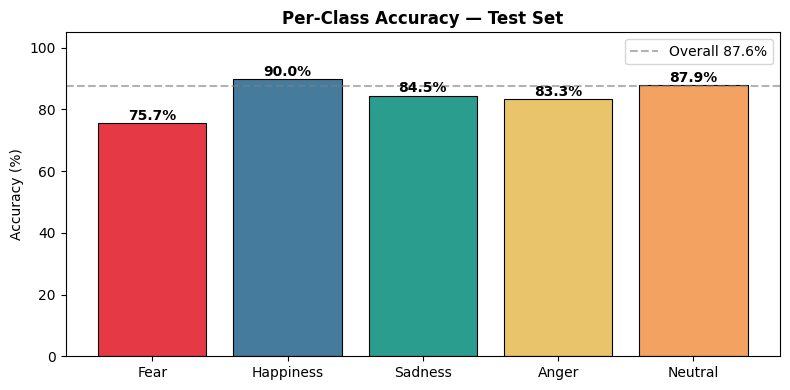

In [4]:
# ── Per-class accuracy breakdown ─────────────────────────
from sklearn.metrics import confusion_matrix
import numpy as np

cm       = confusion_matrix(test_targets, test_preds)
per_cls  = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4))
bars = plt.bar(EM_NAMES, per_cls * 100,
               color=["#E63946","#457B9D","#2A9D8F","#E9C46A","#F4A261"],
               edgecolor="black", linewidth=0.8)
plt.axhline(test_acc * 100, ls="--", color="gray", alpha=0.6, label=f"Overall {test_acc*100:.1f}%")
plt.title("Per-Class Accuracy — Test Set", fontweight="bold")
plt.ylabel("Accuracy (%)"); plt.ylim(0, 105)
for b, v in zip(bars, per_cls):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"{v*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "per_class_accuracy.png"), dpi=150)
plt.show()